# PROYECTO EDA: Análisis del Mercado Inmobiliario Turístico en Málaga (2025)
*Autoras:  Marta Harana Herrera & María Rodríguez Esteras*

---
## Introducción y Enfoque Ejecutivo
Este cuaderno interactivo (`main.ipynb`) constituye el eje central de nuestra investigación. Integra de forma secuencial y enlazada las 5 fases metodológicas de nuestro Análisis Exploratorio de Datos (EDA). El objetivo es desgranar el comportamiento de los alojamientos de Airbnb en la ciudad de Málaga, rompiendo mitos populares y aportando certidumbre estadística para inversores y gestores del sector..

## FASE 1 & 2: Business Case & Data Understanding
Partimos de un problema de negocio claro: *¿Bajo qué condiciones y en qué zonas es competitivo el mercado de Málaga?* Para responderlo, recolectamos el dataset original `listings.csv` que contiene los registros históricos de la plataforma. En esta primera aproximación evaluamos las dimensiones del problema y construimos nuestro diccionario de datos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Carga de datos originales del dataset original
df_original = pd.read_csv("src/data/listings.csv")
print(f"Dimensiones del dataset original: {df_original.shape[0]} filas y {df_original.shape[1]} columnas.")

Dimensiones del dataset original: 9714 filas y 18 columnas.


## FASE 3: Data Cleaning & Preprocessing
Los datos originales presentaban un alto nivel de ruido, como precios formateados como texto (con símbolos de moneda y comas), valores nulos y registros antiguos. Además, consideramos que nos faltaba cierta información, así que obtuvimos columnas de otro dataset de la misma ubicación.

Para garantizar la calidad de las conclusiones, aplicamos un *data pipeline* estructurado de la siguiente manera, junto a su bloque de código:

1. Exploración de los datos inicial y vistazo de los primeros registros

In [2]:
df_original.info()
df_original.head()

<class 'pandas.DataFrame'>
RangeIndex: 9714 entries, 0 to 9713
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              9714 non-null   int64  
 1   name                            9714 non-null   str    
 2   host_id                         9714 non-null   int64  
 3   host_name                       9714 non-null   str    
 4   neighbourhood_group             0 non-null      float64
 5   neighbourhood                   9714 non-null   str    
 6   latitude                        9714 non-null   float64
 7   longitude                       9714 non-null   float64
 8   room_type                       9714 non-null   str    
 9   price                           8815 non-null   float64
 10  minimum_nights                  9714 non-null   int64  
 11  number_of_reviews               9714 non-null   int64  
 12  last_review                     8709 non-null

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,96033,"Bonito piso a 200m de la playa, El Palo (Málaga)",510467,Rafael,NaN,Este,36.720310,-4.356270,Entire home/apt,58.0,3,274,2025-09-29,1.88,1,324,40,ESFCTU0000290200003588210000000000000000VUT/MA...
1,166473,Perfect Location In Malaga,793360,Fred,NaN,Este,36.720310,-4.361080,Private room,28.0,5,102,2025-03-27,0.59,5,288,3,NaN
2,330760,Malaga Lodge Guesthouse Double room-shared bath.,1687526,Mayte,NaN,Centro,36.729786,-4.413462,Private room,60.0,1,68,2025-09-04,0.41,6,64,12,ESHFTU0000290200004234200060000000000000VFT/MA...
3,340024,NEW APARTMENT IN MALAGA CENTER,1725690,Carlos,NaN,Centro,36.728130,-4.414220,Entire home/apt,61.0,3,322,2025-09-09,2.11,1,297,38,VFT/MA/02334
4,358541,Casa La Maga - Apartment for happy people,1526932,Cristina,NaN,Centro,36.723740,-4.421300,Entire home/apt,87.0,2,405,2025-07-27,2.48,1,195,23,VFT/MA/02288


2. Carga de un nuevo dataset, del cual nos queremos quedar con varias de sus columnas. Las seleccionamos y las unimos al dataset original.

In [3]:
# Cargamos el nuevo dataset para añadir las columnas que nos interesan
df_detallado = pd.read_csv("src/data/detallado.csv.gz")

# Seleccionamos las columnas que queremos añadir al original
df_extra = df_detallado[['id', 'accommodates', 'review_scores_rating']]

# Hacemos el merge con el dataset antiguo
df_final = df_original.merge(df_extra, on='id', how='left')

3. Eliminamos las columnas que no nos interesan para el análisis y, tras un estudio de cardinalidades, determinamos que la columna 'id' será el índice, por su cardinalidad del 100%.  
  
Comentar además que nuestro dataset recibirá el nombre de 'df_2025', porque nos quedaremos con todos los registros de ese año, para asegurarnos datos actualizados.

In [4]:
# Eliminamos las columnas previamente seleccionadas
df_main = df_final.drop(columns=["neighbourhood_group", "latitude", "longitude"])

# Utilizaremos la columna id como índice ya que tiene una cardinalidad del 100%
df_main.set_index("id", inplace=True)

4. Nos aseguramos que los tipos de los datos son los correctos. Nosotras convertimos 'last_review' a formato datetime. 

In [5]:
# Convertir 'last_review' a formato fecha
df_main['last_review'] = pd.to_datetime(df_main['last_review'], format='%Y-%m-%d')

# Filtramos para quedarnos con los registros relativos a 2025
df_main = df_main[df_main["last_review"].dt.year == 2025]

5. Llevamos a cabo un estudio de los nulos y obtuvimos como resultado 2 columnas con valores nulos, 'price' (con 477) y 'license' (con 56). Al considerar la primera como una columna de alto valor y determinante en los estudios de hipótesis, optamos por borrar las filas de las que no se conoce el precio del alojamiento, lo que además suponía un 6.5% del total.   
En cuanto a la de 'license',decidimos no imputar ni eliminar esos registros, ya que su ausencia no se considera como un error del dataset, sino al contrario, se podría considerar como una característica con información útil para el análisis posterior.

In [6]:
# Eliminamos las filas que presentan precios nulos solo de la columna 'price'.
df_main = df_main.dropna(subset=["price"])

6. Se identificaron los valores atípicos que pudieran sesgar nuestro análisis, especialente en valores críticos. Como los outliers no siempre son errores, simplemente los detectamos y comentamos para tenerlos presentes a lo largo del estudio.

In [7]:
# Usamos describe para ver máximos y mínimos sospechosos
print("Resumen estadístico de variables numéricas:")
df_main[['price', 'minimum_nights', 'number_of_reviews']].describe()

Resumen estadístico de variables numéricas:


,price,minimum_nights,number_of_reviews
count,6861.000000,6861.000000,6861.000000
mean,199.602973,2.716805,65.558956
std,885.409832,7.663654,92.460037
min,18.000000,1.000000,1.000000
25%,75.000000,1.000000,10.000000
50%,99.000000,2.000000,30.000000
75%,137.000000,3.000000,83.000000
max,21911.000000,365.000000,1110.000000


 Añadimos además un breve comentario acerca de lo que detectamos (en cursiva):

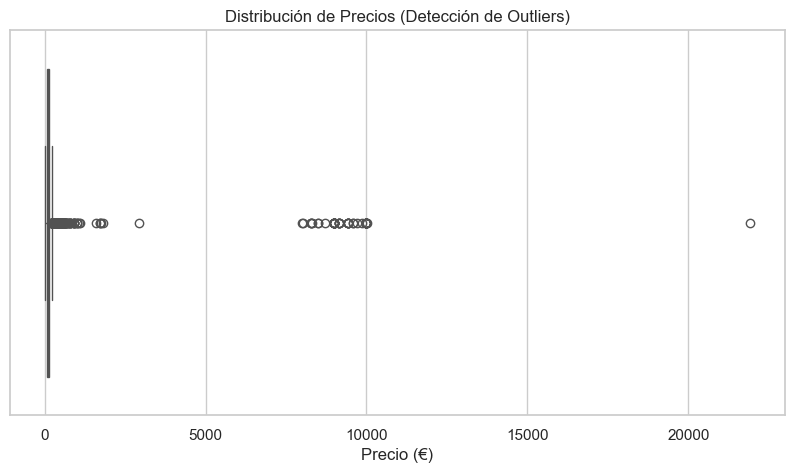

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el estilo
sns.set_theme(style="whitegrid")

# Creamos un gráfico de caja para el Precio
plt.figure(figsize=(10, 5))
sns.boxplot(x=df_main['price'], color='#4ab8c8')
plt.title('Distribución de Precios (Detección de Outliers)')
plt.xlabel('Precio (€)')
plt.show()

*Como se aprecia en el Boxplot anterior, existe un sesgo extremo en la variable price. La presencia de valores atípicos por encima de los 4.000€ impide observar la distribución de la mayoría de la oferta. Procedemos a filtrar la visualización para entender mejor el mercado real.*

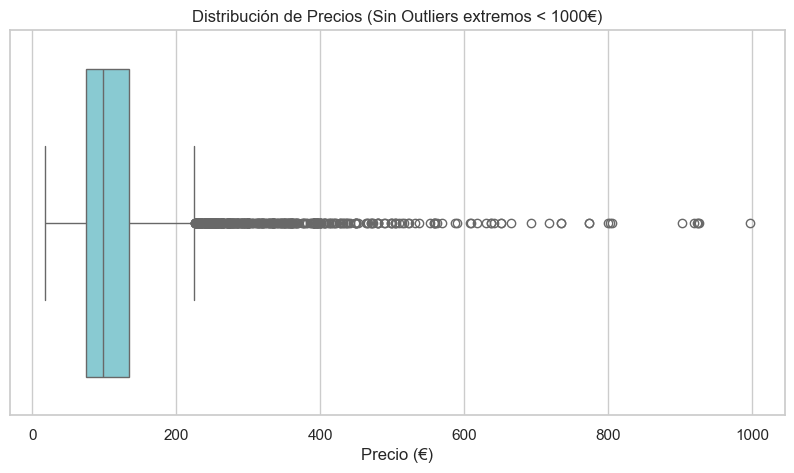

Registros totales: 6861
Registros con precio > 1000€: 69


In [9]:
# Filtramos temporalmente para el gráfico (por ejemplo, precios menores a 1000€)
df_filtrado_precio = df_main[df_main['price'] < 1000]

plt.figure(figsize=(10, 5))
sns.boxplot(x=df_filtrado_precio['price'], color='#7dd4de')
plt.title('Distribución de Precios (Sin Outliers extremos < 1000€)')
plt.xlabel('Precio (€)')
plt.show()

print(f"Registros totales: {len(df_main)}")
print(f"Registros con precio > 1000€: {len(df_main[df_main['price'] >= 1000])}")

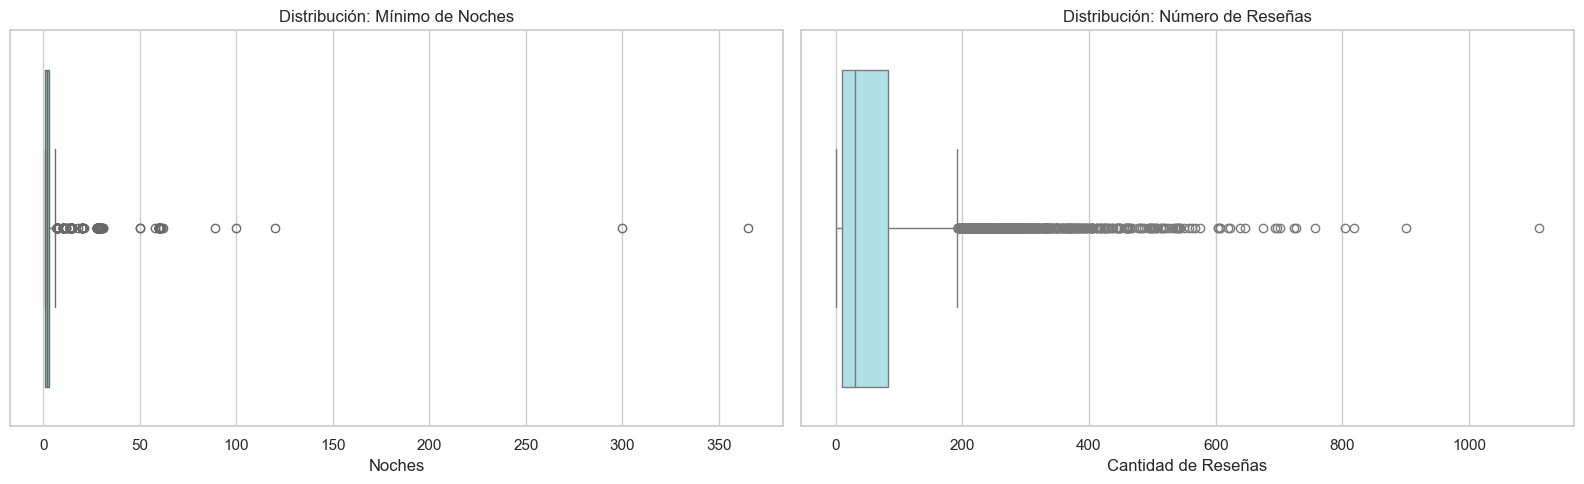

In [10]:
# Configuramos la figura para dos gráficos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# 1. Boxplot para Mínimo de Noches
sns.boxplot(x=df_main['minimum_nights'], ax=ax1, color='#7dd4de')
ax1.set_title('Distribución: Mínimo de Noches')
ax1.set_xlabel('Noches')

# 2. Boxplot para Número de Reseñas
sns.boxplot(x=df_main['number_of_reviews'], ax=ax2, color='#a8e6ef')
ax2.set_title('Distribución: Número de Reseñas')
ax2.set_xlabel('Cantidad de Reseñas')

plt.tight_layout()
plt.show()

*Mínimo de Noches(izquierda): La gran mayoría de los alojamientos en Málaga se sitúan por debajo de las 7 noches. Los valores que vemos extendiéndose hacia la derecha representan casos atípicos (alquileres de larga estancia o bloqueos de calendario) que deben ser tratados para no desvirtuar el análisis del comportamiento turístico.*

*Número de Reseñas: Se observa una distribución con sesgo positivo muy marcado. Aunque la mayoría de los pisos tienen pocas reseñas, los outliers que superan las 200-400 críticas identifican a los "Veteranos" de la plataforma, aquellos con mayor éxito y rotación histórica.*

Decisión sobre el filtrado:
Tras el análisis visual de outliers en price, minimum_nights y number_of_reviews, se ha optado por mantener la totalidad de los registros en el DataFrame actual. Justificación:

- Los valores atípicos en el precio representan el segmento de lujo de Málaga 2025.

- Las estancias mínimas elevadas y el alto volumen de reseñas son comportamientos reales del mercado que podrían ser objeto de estudio específico más adelante.

- En la Fase de "Análisis Exploratorio", si alguna visualización se ve distorsionada por estos valores, se aplicarán filtros locales o escalas logarítmicas para facilitar la interpretación sin perder la integridad del dataset original.

7. Buscamos duplicados y no encontramos:

In [11]:
duplicados = df_main.duplicated().sum()
print(f"Número de registros duplicados detectados: {duplicados}")

Número de registros duplicados detectados: 0


8. Creamos variables nuevas por medio de transformaciones, que para no repetir, las colocaremos en su correcta ubicación dentro de cada uno de los estudios de las hipótesis.

In [12]:
# Cargamos directamente el dataset limpio resultante de la Fase 3
df_2025 = pd.read_csv("src/data/df_2025.csv")
print(f"Dimensiones tras el proceso de ingeniería de datos (Dataset Optimizado 2025): {df_final.shape}")
print(f"Total de registros ruidosos u obsoletos eliminados: {len(df_original) - len(df_main)}")

Dimensiones tras el proceso de ingeniería de datos (Dataset Optimizado 2025): (9714, 20)
Total de registros ruidosos u obsoletos eliminados: 2853


## FASE 4: Análisis Exploratorio de Datos (EDA)
Con el dataset limpio de 6.861 registros, procedemos a contrastar las tres hipótesis fundamentales que guían nuestra investigación de negocio.

### Hipótesis 1: El factor geográfico determina el precio
* **Enunciado:** Los alojamientos ubicados en el Centro tienen precios significativamente más altos que en el resto de los barrios de Málaga.
* **Intuición de partida:** El Centro concentra la gran masa de la oferta turística y el mayor volumen de demanda cultural, lo que razonablemente debería elevar las tarifas por noche.
* **Enfoque analítico:** Para contrastar este supuesto, no solo analizamos el precio plano por distrito, sino que desgregamos las métricas según el tipo de propiedad (`room_type`) y el volumen de oferta por anfitrión, descubriendo dinámicas competitivas ocultas.

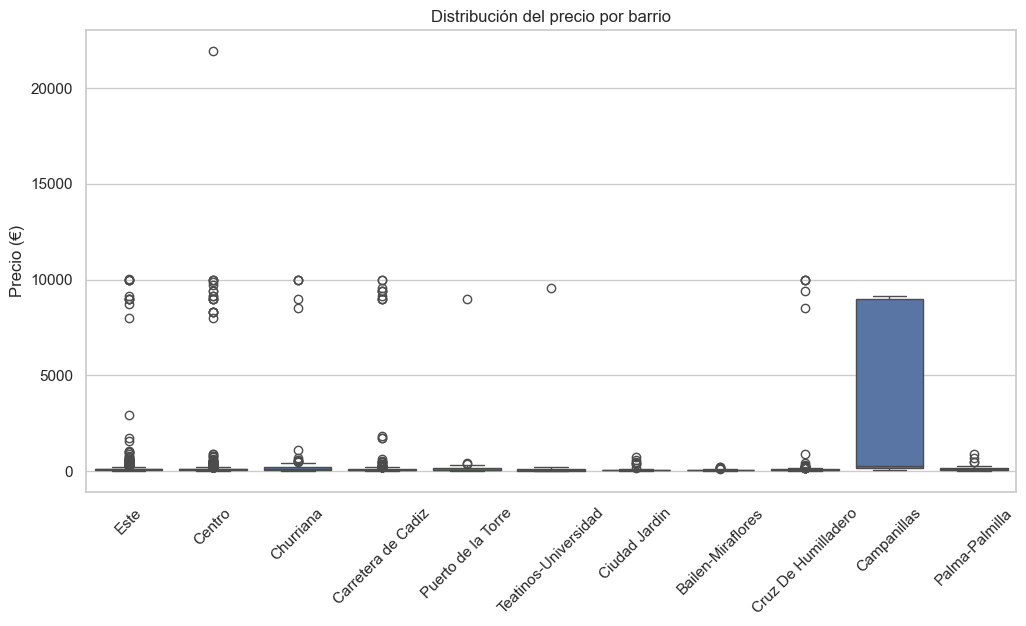

In [13]:
# Boxplot de la distribución del precio por barrio
plt.figure(figsize=(12,6))
sns.boxplot(data=df_2025, x="neighbourhood", y="price")
plt.xticks(rotation=45)
plt.title("Distribución del precio por barrio")
plt.xlabel("")
plt.ylabel("Precio (€)", fontsize = 12)
plt.show()

In [14]:
df_2025.groupby("neighbourhood")["price"].describe()

,count,mean,std,min,25%,50%,75%,max
neighbourhood,,,,,,,,
Bailen-Miraflores,217.0,73.589862,34.870030,18.0,52.0,72.0,89.00,249.0
Campanillas,19.0,2989.210526,4213.307682,56.0,157.5,259.0,9000.00,9143.0
Carretera de Cadiz,666.0,251.097598,1138.625287,23.0,70.0,93.0,124.75,9999.0
Centro,4615.0,157.234670,650.193770,20.0,78.0,101.0,138.00,21911.0
Churriana,110.0,594.290909,1963.638447,27.0,75.0,111.5,231.75,9999.0
Ciudad Jardin,52.0,113.134615,151.273292,22.0,48.0,63.0,83.50,735.0
Cruz De Humilladero,294.0,255.663265,1233.656016,19.0,60.0,84.0,108.00,10000.0
Este,689.0,310.222061,1218.329532,22.0,79.0,101.0,150.00,10014.0
Palma-Palmilla,123.0,141.650407,116.655650,25.0,80.5,127.0,169.00,926.0


Descartamos la media como medida representativa, ya que la desviación típica es elevada en todos los barrios, lo que indica una fuerte 
dispersión y presencia de valores extremos. Por ello, utilizamos la mediana como estadístico central más robusto y ordenamos los barrios
de forma descendente según su mediana de precios.


Mediana de precios por barrio:
           neighbourhood  price
0            Campanillas  259.0
1         Palma-Palmilla  127.0
2              Churriana  111.5
3                   Este  101.0
4                 Centro  101.0
5     Puerto de la Torre   99.0
6     Carretera de Cadiz   93.0
7    Cruz De Humilladero   84.0
8      Bailen-Miraflores   72.0
9          Ciudad Jardin   63.0
10  Teatinos-Universidad   63.0


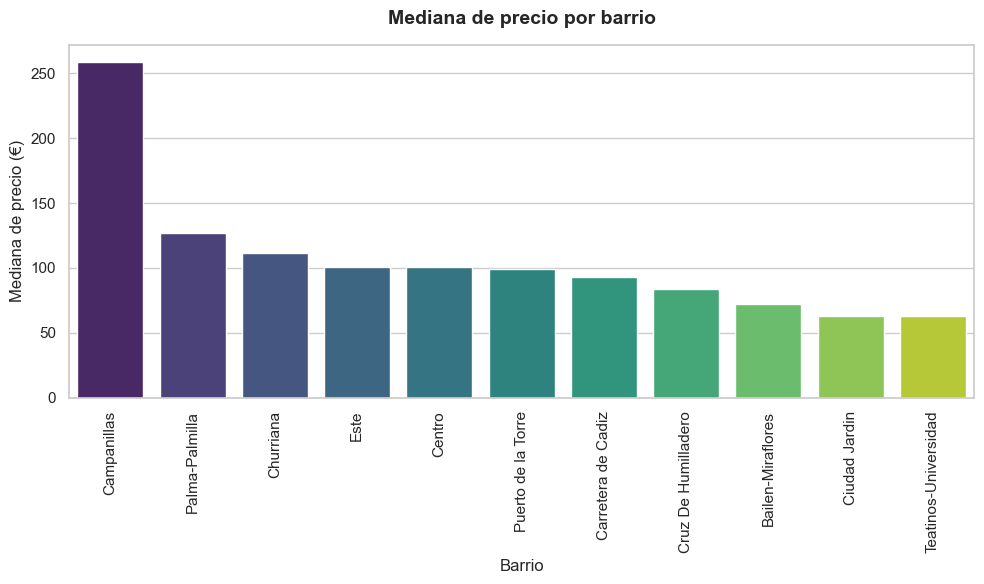

In [15]:
# 1. Agrupamos por barrio y calculamos la mediana del precio, ordenando de mayor a menor
precios_por_barrio = (
    df_2025.groupby("neighbourhood")["price"]
    .median()
    .sort_values(ascending=False)
    .reset_index()
)

# Mostramos el dataframe resultante para ver los datos numéricos exactos
print("Mediana de precios por barrio:")
print(precios_por_barrio)

# 2. Creamos la figura con el tamaño adecuado
plt.figure(figsize=(10, 6))

# 3. Dibujamos el gráfico de barras verticales
# Usamos 'neighbourhood' en el eje X y 'price' en el eje Y
sns.barplot(
    x='neighbourhood', 
    y='price', 
    data=precios_por_barrio, 
    palette='viridis'  # Genera el degradado de colores de tu captura
)

# 4. Añadimos títulos y etiquetas
plt.title('Mediana de precio por barrio', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Barrio', fontsize=12)
plt.ylabel('Mediana de precio (€)', fontsize=12)

# 5. Rotamos los nombres del eje X para que se lean perfectamente en vertical
plt.xticks(rotation=90)

# Ajustamos el diseño y mostramos
plt.tight_layout()
plt.show()

Se utiliza la mediana del precio por barrio como medida principal de tendencia central, ya que es menos sensible a valores extremos y ofrece una visión más fiel del comportamiento típico sin requerir la eliminación de outliers.  

Al comparar la media y la mediana por barrio, observamos que la media presenta valores anormalmente altos en algunas zonas. Esto se debe a la presencia de alojamientos con precios muy elevados (muy por encima del mercado) que inflan el valor de la media. Estos valores extremos suelen corresponder a viviendas de lujo o propiedades ubicadas en zonas residenciales exclusivas.  

La mediana, en cambio, permite describir el precio típico de cada barrio sin que estos casos excepcionales distorsionen el análisis, proporcionando una representación más robusta y realista del comportamiento general del mercado.

A continuación, realizamos un análisis de los outliers, detectando que todos ellos corresponden a apartamentos completos, probablemente de alta gama al contar con un número escaso de reseñas. Todos cuentan con licencia y presentan una disponibilidad anual alta, para estancias de corta duración (vacaciones).

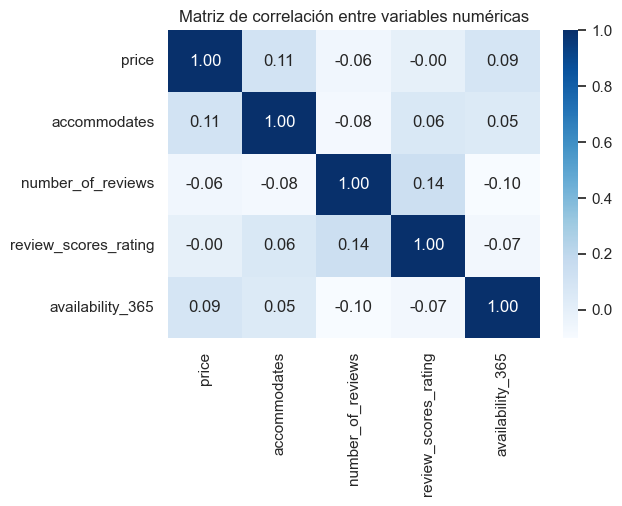

In [16]:
correlaciones = df_2025[["price", "accommodates", "number_of_reviews", "review_scores_rating", "availability_365"]].corr()
correlaciones

# Generamos un mapa de calor para verlo de forma mas visual
plt.figure(figsize=(6,4))
sns.heatmap(correlaciones, annot=True, cmap="Blues", fmt=".2f")
plt.title("Matriz de correlación entre variables numéricas")
plt.show()

La matriz de correlación muestra que no existen relaciones lineales fuertes entre las variables numéricas analizadas. El precio presenta correlaciones muy bajas con la capacidad, el número de reseñas, la puntuación y la disponibilidad, lo que indica que estos factores no explican de forma directa las variaciones de precio. La única relación ligeramente destacable es la correlación positiva entre número de reseñas y rating, aunque sigue siendo débil.  

También se observa una correlación negativa entre reseñas y disponibilidad, coherente con el hecho de que los alojamientos más reservados acumulan más reseñas y tienen menos días libres.  

En conjunto, las correlaciones sugieren que el precio y la actividad de los alojamientos dependen de factores no numéricos o no incluidos en este conjunto de variables.

Ahora estudiamos la distribución del precio por tipo de habitación.

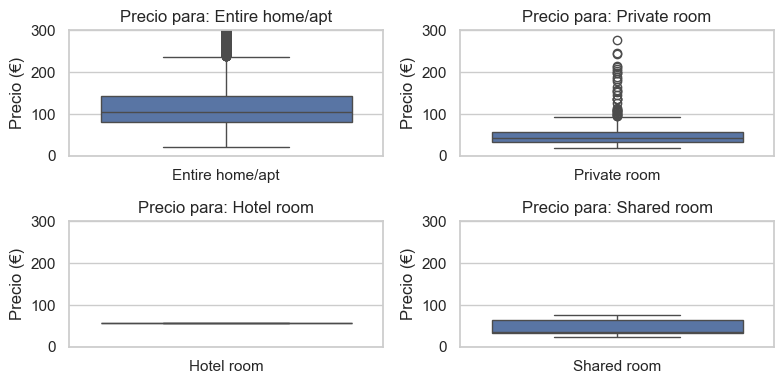

In [17]:
# Distribución del precio por tipo de habitación
 
tipos = df_2025["room_type"].unique()

fig, axes = plt.subplots(2, 2, figsize=(8, 4))
axes = axes.flatten()

for i, tipo in enumerate(tipos):
    sns.boxplot(
        data=df_2025[df_2025["room_type"] == tipo],
        x="room_type",
        y="price",
        ax=axes[i]
    )
    axes[i].set_title(f"Precio para: {tipo}")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Precio (€)")
    axes[i].set_ylim(0, 300)  # ajustamos el límite del eje y para ver los valores mas bajos

plt.tight_layout()
plt.show()

Los diagramas de caja muestran diferencias claras entre los tipos de alojamiento. Los apartamentos completos (Entire home/apt) presentan los precios más altos y también la mayor variabilidad, con numerosos valores extremos que indican la presencia de alojamientos significativamente más caros. Las habitaciones privadas (Private room) tienen precios mucho más bajos y una distribución más concentrada, aunque también aparecen algunos outliers. Las habitaciones compartidas (Shared room) son las más económicas y muestran una variabilidad reducida. Por su parte, las habitaciones de hotel (Hotel room) presentan precios intermedios y una distribución relativamente estable. 
 
En conjunto, los resultados confirman que los alojamientos completos son claramente más caros, mientras que las habitaciones privadas y compartidas ofrecen opciones más económicas y homogéneas.

Analizamos la relación entre capacidad y precio con la mediana.

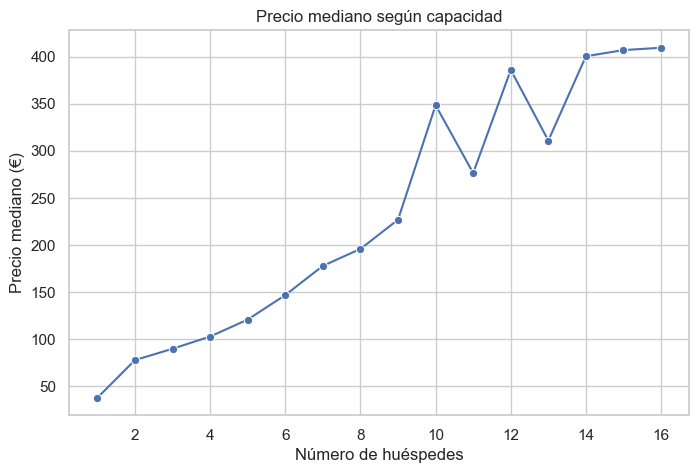

In [18]:
# Relación entre capacidad y precio (mediana)

medianas = df_2025.groupby("accommodates")["price"].median().reset_index()

plt.figure(figsize=(8,5))
sns.lineplot(
    data=medianas,
    x="accommodates",
    y="price",
    marker="o"
)
plt.title("Precio mediano según capacidad")
plt.xlabel("Número de huéspedes")
plt.ylabel("Precio mediano (€)")
plt.show()


El gráfico de la mediana del precio según la capacidad muestra una tendencia ascendente clara: a medida que aumenta el número de huéspedes que pueden alojarse en un apartamento , también lo hace el precio mediano. Aunque existen pequeñas fluctuaciones en capacidades altas, la tendencia general confirma que los alojamientos más grandes tienden a ser más caros.

Llevamos a cabo ahora un análisis multivariante entre la mediana (€), localización y el tipo de habitación

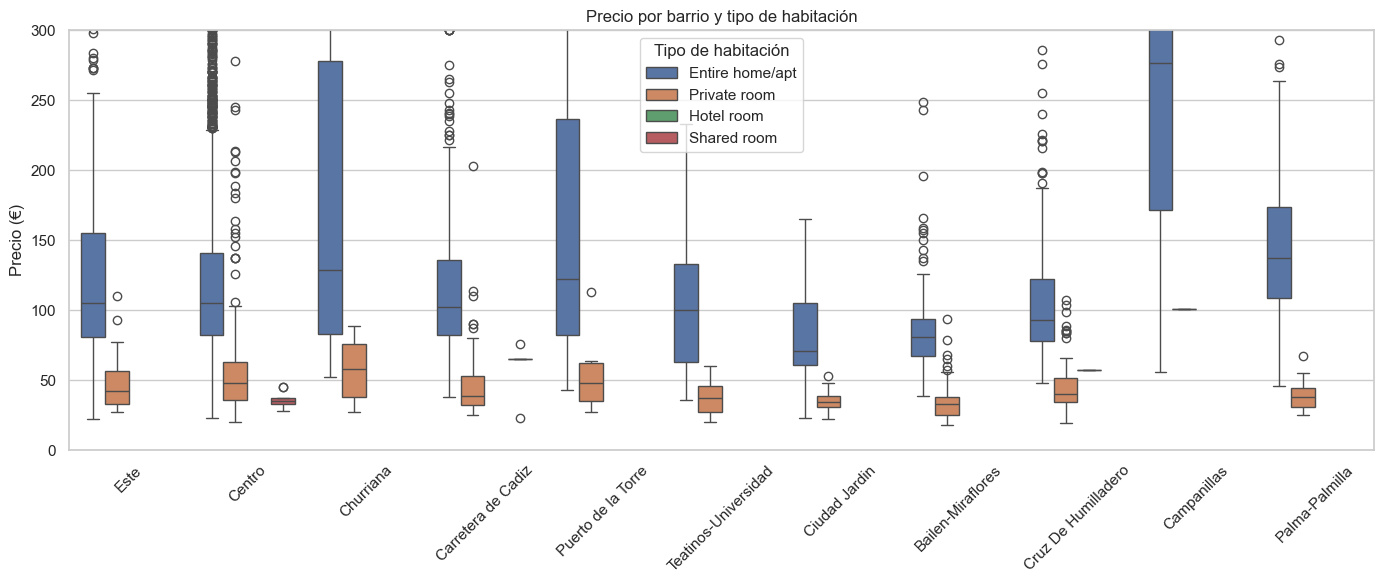

In [19]:
plt.figure(figsize=(14,6))
sns.boxplot(
    data=df_2025,
    x="neighbourhood",
    y="price",
    hue="room_type"
)
plt.xticks(rotation=45)
plt.title("Precio por barrio y tipo de habitación")
plt.ylabel("Precio (€)")
plt.xlabel("")
plt.legend(title="Tipo de habitación")
plt.ylim(0, 300)  # para evitar que los outliers aplasten el gráfico
plt.tight_layout()
plt.show()


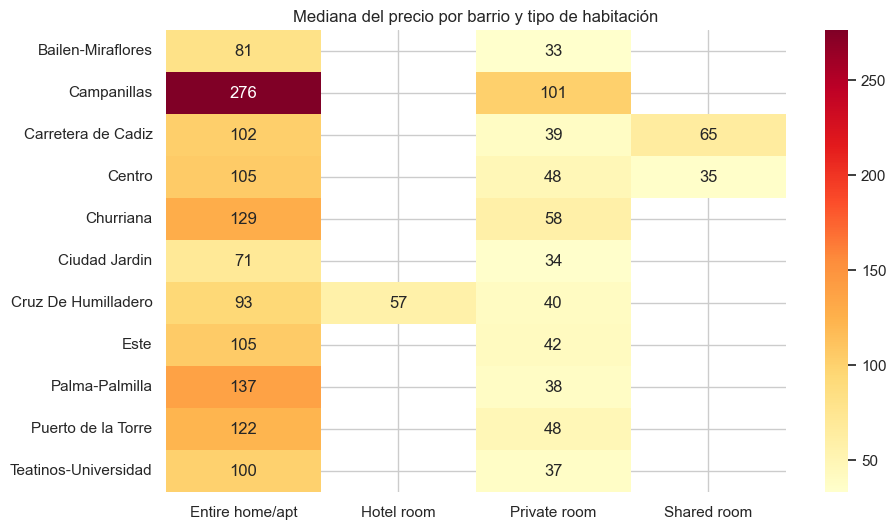

In [20]:
tabla = df_2025.pivot_table(
    values="price",
    index="neighbourhood",
    columns="room_type",
    aggfunc="median"
)

plt.figure(figsize=(10,6))
sns.heatmap(tabla, annot=True, fmt=".0f", cmap="YlOrRd")
plt.title("Mediana del precio por barrio y tipo de habitación")
plt.xlabel("")
plt.ylabel("")
plt.show()

La comparación entre el boxplot por barrio y tipo de habitación y el heatmap de medianas permite reforzar las conclusiones del análisis multivariante. Mientras que el boxplot muestra la dispersión y variabilidad interna de los precios en cada combinación de barrio y tipo de alojamiento, el heatmap sintetiza esa información destacando las tendencias centrales de forma clara y comparativa. Juntos, ambos gráficos revelan que las viviendas completas son sistemáticamente más caras en todos los barrios, aunque con variaciones notables según la zona, y que las habitaciones privadas y compartidas mantienen precios más homogéneos. Esta combinación de visualizaciones confirma que la localización y el tipo de habitación interactúan de manera decisiva en la determinación del precio, ofreciendo una visión más completa que cualquiera de los gráficos por separado.  

Analizando el precio (mediana) y el número de reseñas...

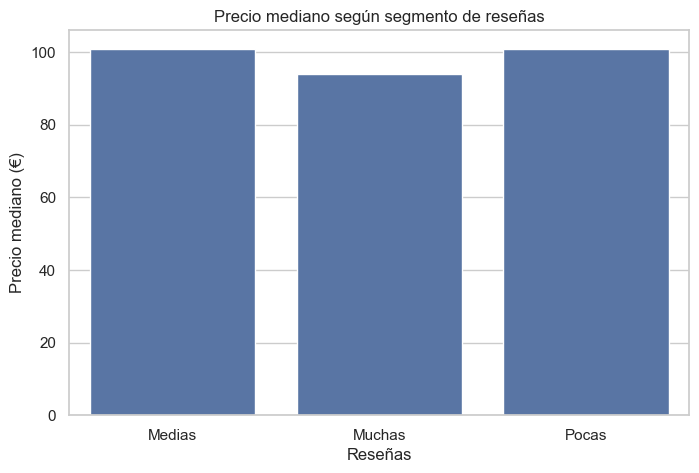

In [21]:
medianas_seg = df_2025.groupby("Segmento Reseñas")["price"].median().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=medianas_seg, x="Segmento Reseñas", y="price")
plt.title("Precio mediano según segmento de reseñas")
plt.xlabel("Reseñas")
plt.ylabel("Precio mediano (€)")
plt.show()


In [22]:
df_2025["number_of_reviews"].corr(df_2025["price"])

np.float64(-0.06061398372488425)

El análisis del precio por segmento de reseñas muestra que no existe una relación clara entre ambas variables. Los alojamientos con muchas reseñas presentan precios medianos ligeramente inferiores, pero las diferencias entre segmentos son pequeñas y no siguen un patrón consistente.  

A continuación, analizamos el precio (mediana) y disponibilidad anual.

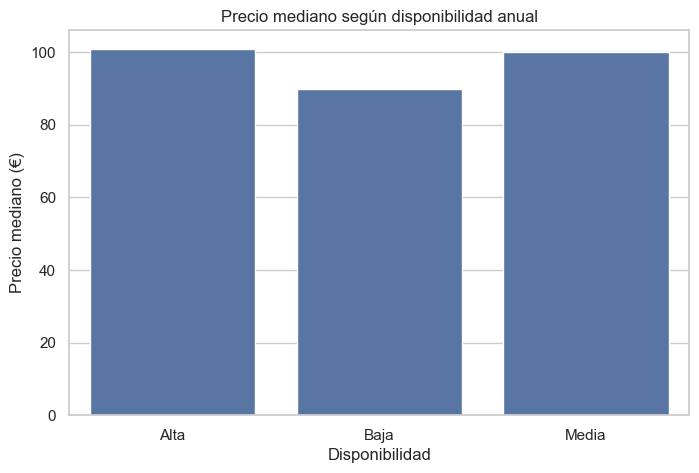

In [23]:
medianas_disp = df_2025.groupby("disponibilidad_clasificacion")["price"].median().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=medianas_disp, x="disponibilidad_clasificacion", y="price")
plt.title("Precio mediano según disponibilidad anual")
plt.xlabel("Disponibilidad")
plt.ylabel("Precio mediano (€)")
plt.show()


In [24]:
df_2025["availability_365"].corr(df_2025["price"])

np.float64(0.08778137068158547)

La correlación entre disponibilidad anual y precio es de 0.08, un valor extremadamente bajo que indica ausencia de relación lineal entre ambas variables. Esto confirma que la disponibilidad no depende del precio, y que la demanda está influida por otros factores como la ubicación, el tipo de alojamiento o la capacidad del alojamiento.

Ahra, analizamos la duración mínima del alojamiento (estancia)

In [25]:
moda_estancia_barrio = df_2025.groupby("neighbourhood")["estancia_clasificacion"].agg(lambda x: x.mode().iloc[0])
moda_estancia_barrio

neighbourhood
Bailen-Miraflores       Corta
Campanillas             Corta
Carretera de Cadiz      Corta
Centro                  Corta
Churriana               Corta
Ciudad Jardin           Corta
Cruz De Humilladero     Corta
Este                    Corta
Palma-Palmilla          Corta
Puerto de la Torre      Corta
Teatinos-Universidad    Corta
Name: estancia_clasificacion, dtype: str

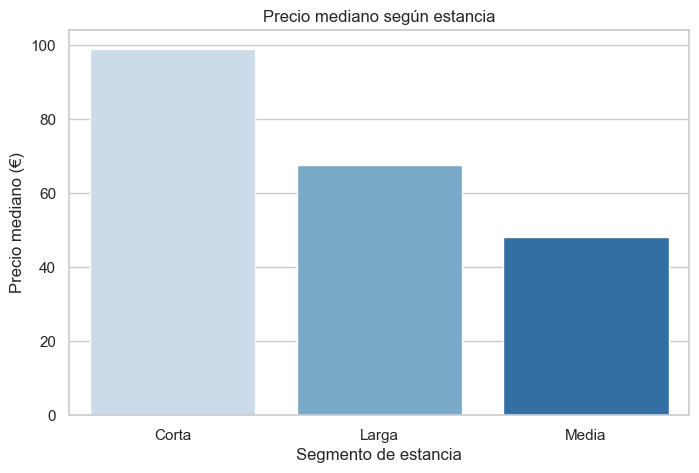

In [26]:
medianas_estancia = df_2025.groupby("estancia_clasificacion")["price"].median().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=medianas_estancia, x="estancia_clasificacion", y="price", palette="Blues")
plt.title("Precio mediano según estancia")
plt.xlabel("Segmento de estancia")
plt.ylabel("Precio mediano (€)")
plt.show();

El análisis del precio mediano por segmento de estancia muestra diferencias claras entre los tipos de alojamiento. Las estancias cortas son las más caras, seguidas por las estancias largas, mientras que las estancias de duración media presentan los precios más bajos. Este patrón es coherente con el comportamiento habitual del mercado turístico: las estancias cortas suelen tener un precio por noche más elevado debido a la alta rotación y a los costes fijos asociados, mientras que las estancias largas tienden a beneficiarse de descuentos progresivos. Por su parte, las estancias medias se sitúan en un punto intermedio, donde la tarifa por noche suele ser más competitiva para atraer a viajeros que buscan una estancia prolongada pero no mensual.  

Y por último, analizamos el precio medio por barrio según el tipo de host.

In [27]:
moda_host_barrio = (
    df_2025.groupby("neighbourhood")["host_type"]
      .agg(lambda x: x.mode()[0])
      .reset_index()
)

moda_host_barrio

,neighbourhood,host_type
0,Bailen-Miraflores,Particular
1,Campanillas,Particular
2,Carretera de Cadiz,Semi-profesional
3,Centro,Empresa/Hotel
4,Churriana,Particular
5,Ciudad Jardin,Particular
6,Cruz De Humilladero,Semi-profesional
7,Este,Semi-profesional
8,Palma-Palmilla,Empresa/Hotel
9,Puerto de la Torre,Particular


### Conclusión y Diagnóstico de la Hipótesis 1

**La hipótesis SE RECHAZA de forma contundente.** El Distrito Centro no registra las tarifas más altas de Málaga, situándose en un rango intermedio-alto por detrás de distritos como Churriana o Este.

Para entender este fenómeno (que contradice la intuición inicial), el análisis desveló cuatro factores clave en la estructura del mercado de Málaga:

1. **El Efecto de la Competencia Feroz:** El Centro sufre una saturación de oferta. Al haber tanta competencia directa de alojamientos de características similares, los precios se autorregulan a la baja para poder captar clientes.
2. **Profesionalización de los Anfitriones (Multi-hosts):** Los datos reflejan que los alojamientos del Centro están mayoritariamente controlados por gestores profesionales. Estos actores aplican estrategias de precios dinámicos muy optimizadas; prefieren mantener un precio moderado que asegure un 90% de ocupación mensual a inflar los precios y arriesgarse a tener el piso vacío.
3. **Composición de la Oferta (Tipología de Vivienda):** En barrios como *Churriana* o *Este*, la mediana se dispara porque la tipología de vivienda dominante es diferente: abundan las villas, chalets y casas grandes con piscina. En el Centro, la oferta está homogeneizada en apartamentos y estudios de menor tamaño, lo que arrastra la mediana hacia abajo.
4. **Resiliencia frente a Outliers:** En distritos periféricos más pequeños, la presencia de unas pocas propiedades de lujo afecta notablemente a los estadísticos. En cambio, el gigantesco volumen de muestras del Centro absorbe cualquier propiedad de súper lujo sin que la mediana general se vea alterada.

*Nota de coherencia interna:* Este hallazgo conecta directamente con la **Hipótesis 2**, donde validamos cómo los gestores profesionales eliminan los sesgos de precios en las zonas de alta densidad desde el primer día de publicación.

### Hipótesis 2: El precio de los alojamientos con pocas reseñas es más alto que el de los que tienen muchas.
* **Enunciado:** Los alojamientos que disponen de pocas reseñas fijan precios por noche significativamente más altos que aquellos que cuentan con un gran histórico de opiniones.
* **Justificación de negocio:** Explicación de la lógica comercial (los anfitriones novatos suelen carecer de precios optimizados o entran al mercado con precios de prueba altos, mientras que los veteranos ajustan tarifas basándose en el histórico y la necesidad de mantener la ocupación).
* **Enfoque analítico:** Para comprobar si esta teoría es real, calculamos la correlación lineal de Pearson entre las métricas de precio y volumen de reseñas, agrupamos los alojamientos por su nivel de madurez y analizamos la distribución cruzada mediante gráficos multivariantes.

In [28]:
# Variables creadas nuevas:
df_2025['price_per_accommodation'] = df_2025['price'] / df_2025['accommodates'] # Divide precio entre capacidad para evitar analizar "casas grandes" como "caras" erróneamente.

Análisis univariante: entendiendo las variables.

--- Estadísticas descriptivas de 'price' ---
count     6861.000000
mean       199.602973
std        885.409832
min         18.000000
25%         75.000000
50%         99.000000
75%        137.000000
max      21911.000000
Name: price, dtype: float64


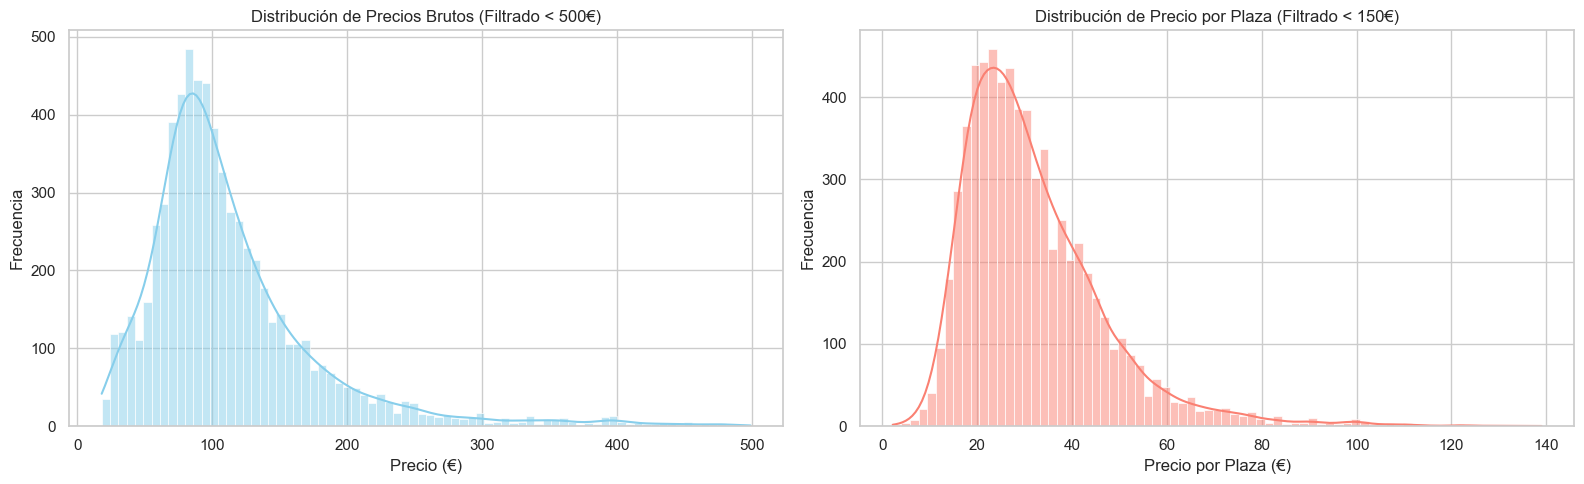


--- Estadísticas descriptivas de 'number_of_reviews' ---
count    6861.000000
mean       65.558956
std        92.460037
min         1.000000
25%        10.000000
50%        30.000000
75%        83.000000
max      1110.000000
Name: number_of_reviews, dtype: float64

Justificación matemática:
- El 25% de los alojamientos tiene 10 reseñas o menos (Grupo 'Pocas').
- El 25% de los alojamientos con más actividad tiene 83 reseñas o más (Grupo 'Muchas').


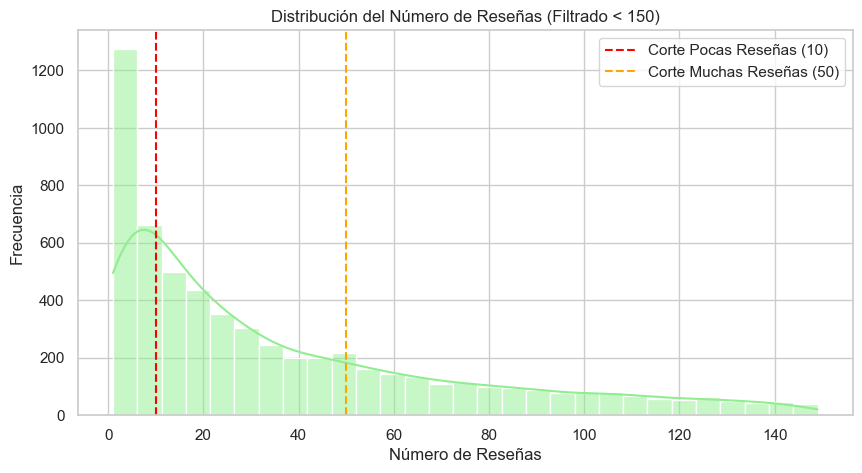


--- Distribución de registros por Segmento de Reseñas ---
Segmento Reseñas
Muchas    2542
Medias    2503
Pocas     1816
Name: count, dtype: int64


In [29]:
# Calculamos las métricas clave de tendencia central y la dispersión
print("--- Estadísticas descriptivas de 'price' ---")
print(df_2025['price'].describe())

# Configuramos la figura para comparar el precio bruto y el precio por plaza
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Histograma 1: Precio Bruto (limitado a < 500€ para eliminar los outliers)
sns.histplot(data=df_2025[df_2025['price'] < 500], x='price', kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Distribución de Precios Brutos (Filtrado < 500€)')
axes[0].set_xlabel('Precio (€)')
axes[0].set_ylabel('Frecuencia')

# Histograma 2: Precio por Plaza (limitado a < 150€ para mejor visualización)
sns.histplot(data=df_2025[df_2025['price_per_accommodation'] < 150], x='price_per_accommodation', kde=True, color='salmon', ax=axes[1])
axes[1].set_title('Distribución de Precio por Plaza (Filtrado < 150€)')
axes[1].set_xlabel('Precio por Plaza (€)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

# 2. Estudio de las reseñas
print("\n--- Estadísticas descriptivas de 'number_of_reviews' ---")
print(df_2025['number_of_reviews'].describe())

# Analizando los percentiles importantes para justificar cortes que hagamos
p25 = df_2025['number_of_reviews'].quantile(0.25)
p75 = df_2025['number_of_reviews'].quantile(0.75)
print(f"\nJustificación matemática:")
print(f"- El 25% de los alojamientos tiene {p25:.0f} reseñas o menos (Grupo 'Pocas').")
print(f"- El 25% de los alojamientos con más actividad tiene {p75:.0f} reseñas o más (Grupo 'Muchas').")

# Histograma del volumen de reseñas (limitamos a < 150 reseñas para apreciar la curva)
plt.figure(figsize=(10, 5))
sns.histplot(data=df_2025[df_2025['number_of_reviews'] < 150], x='number_of_reviews', kde=True, color='lightgreen')
plt.axvline(x=10, color='red', linestyle='--', label='Corte Pocas Reseñas (10)')
plt.axvline(x=50, color='orange', linestyle='--', label='Corte Muchas Reseñas (50)')
plt.title('Distribución del Número de Reseñas (Filtrado < 150)')
plt.xlabel('Número de Reseñas')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

# Segmentación y creación de categorías
# Definimos los cortes basándonos en los criterios de:
# 0-10 (pocas), 10-50 (medias), 50+ (muchas)
cortes = [0, 10, 50, df_2025['number_of_reviews'].max()]
etiquetas = ['Pocas', 'Medias', 'Muchas']

# Aplicamos pd.cut para generar la columna categórica (con el 0 incluido)
df_2025['Segmento Reseñas'] = pd.cut(df_2025['number_of_reviews'], bins=cortes, labels=etiquetas, include_lowest=True)

# Comprobamos la salud de la muestra mostrando el volumen de datos por grupo
print("\n--- Distribución de registros por Segmento de Reseñas ---")
print(df_2025['Segmento Reseñas'].value_counts())

Análisis bivariante: cruzando las variables.  

El objetivo de este bloque es el de validar formalmente las hipótesis cruzando directamente la variable predictora (number_of_reviews / Segmento Reseñas) con la variable objetivo (price).

--- ENFOQUE CUANTITATIVO: CORRELACIÓN DE PEARSON ---
Coeficiente de correlación de Pearson global (Precio vs Reseñas): -0.0606


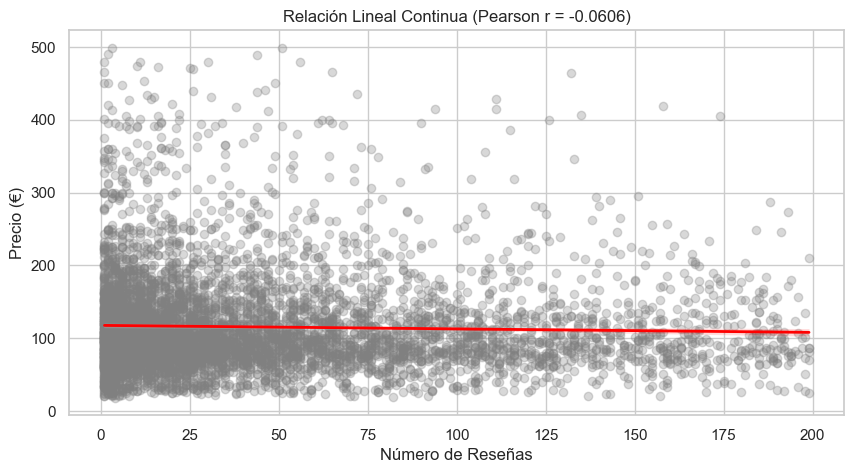


--- ENFOQUE CATEGÓRICO: COMPARACIÓN DE MEDIANAS ---
                   count    50%        mean
Segmento Reseñas                           
Pocas             1816.0  101.0  348.122247
Medias            2503.0  101.0  169.294447
Muchas            2542.0   94.0  123.344611


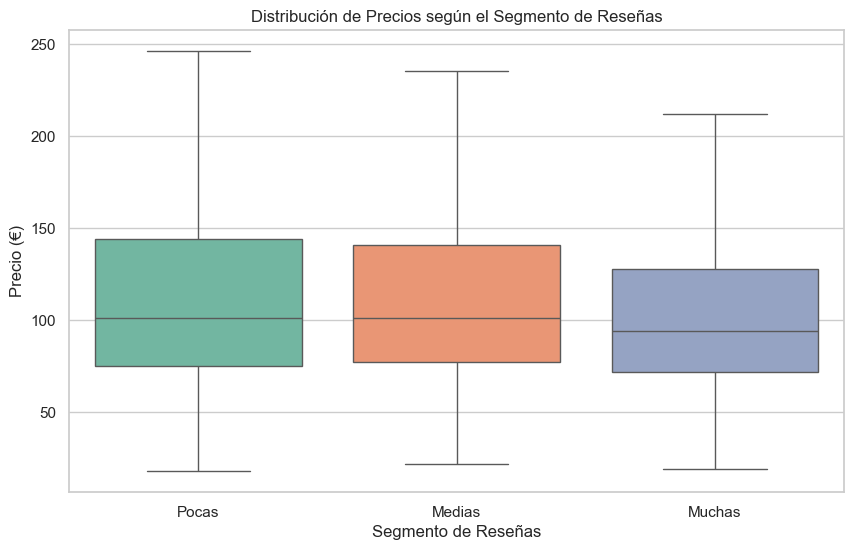

In [30]:
print("--- ENFOQUE CUANTITATIVO: CORRELACIÓN DE PEARSON ---")

# Calculamos el coeficiente de correlación de Pearson del conjunto
correlacion_global = df_2025['price'].corr(df_2025['number_of_reviews'], method='pearson')
print(f"Coeficiente de correlación de Pearson global (Precio vs Reseñas): {correlacion_global:.4f}")

# Gráfico de dispersión con línea de tendencia para observar la relación continua
plt.figure(figsize=(10, 5))

# Limitamos visualmente para evitar que los outliers me 'deformen' el gráfico
df_filtrado_grafico = df_2025[(df_2025['price'] < 500) & (df_2025['number_of_reviews'] < 200)]

sns.regplot(
    data=df_filtrado_grafico, 
    x='number_of_reviews', 
    y='price', 
    scatter_kws={'alpha':0.3, 'color':'gray'}, 
    line_kws={'color':'red', 'linewidth':2}
)
plt.title(f'Relación Lineal Continua (Pearson r = {correlacion_global:.4f})')
plt.xlabel('Número de Reseñas')
plt.ylabel('Precio (€)')
plt.show()


print("\n--- ENFOQUE CATEGÓRICO: COMPARACIÓN DE MEDIANAS ---")

# Resumen estadístico agrupando por los segmentos definidos en el a. univariante
tabla_bivariante = df_2025.groupby('Segmento Reseñas', observed=False)['price'].describe()
print(tabla_bivariante[['count', '50%', 'mean']])

# Gráfico de cajas (Boxplot) para comparar las distribuciones de precio por segmento
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_2025, 
    x='Segmento Reseñas', 
    y='price', 
    showfliers=False, # Oculto outliers extremos 
    palette='Set2'
)
plt.title('Distribución de Precios según el Segmento de Reseñas')
plt.xlabel('Segmento de Reseñas')
plt.ylabel('Precio (€)')
plt.show()

**Interpretación del Análisis Bivariante:**  
1. **Evidencia de la correlación de Pearson ($r = -0.0606$):** El signo negativo del coeficiente de Pearson confirma matemáticamente nuestra hipótesis inicial: existe una tendencia donde a mayor número de reseñas, el precio del alojamiento disminuye. Sin embargo, al estar el valor tan cercano a 0, determinamos que la relación lineal global es extremadamente débil. Esto nos indica que el precio está gobernado por otros factores con mayor peso específico (como la ubicación o el tipo de propiedad) y que el impacto de la veteranía, aunque real, es sutil a nivel macro.  

2. **Análisis de Medianas por Segmento:** Al transformar la variable continua en segmentos cualitativos ("Pocas", "Medias", "Muchas"), el comportamiento de mercado se vuelve mucho más evidente que con la simple línea recta de Pearson:  

    - Los alojamientos catalogados con Pocas reseñas registran la mediana de precio más alta del mercado (101€).  
    - Los alojamientos veteranos con Muchas reseñas muestran una reducción en su precio mediano, situándose en 94€.  
3. **Conclusión del bloque:** Los datos bivariantes respaldan la hipótesis de partida. El "anfitrión novato" o la propiedad que acaba de ser publicada tienden a ingresar a la plataforma con una estrategia de precios más alta o menos optimizada respecto a aquellos que ya han acumulado un histórico considerable de reseñas. Como siguiente paso, el análisis multivariante nos permitirá validar si este comportamiento es uniforme en todos los tipos de habitaciones o si esconde excepciones sectoriales.

Análisis multivariante: El efecto del tipo de habitación.  

El obetivo es desvelar los secretos ocultos de los datos y dar respuesas definitivas de negocio. Vamos a cruzar las reseñas y los precios con el tipo de habitación (room_type), el tipo de anfitrión (host_type) y la disponibilidad (availability_365).

--- EL EFECTO DEL TIPO DE HABITACIÓN ---
Medianas de precio por segmento y tipo de habitación:
room_type         Entire home/apt  Hotel room  Private room  Shared room
Segmento Reseñas                                                        
Pocas                       107.0         NaN          49.0         34.5
Medias                      106.0         NaN          42.0         45.0
Muchas                      100.0        57.0          40.0         50.0


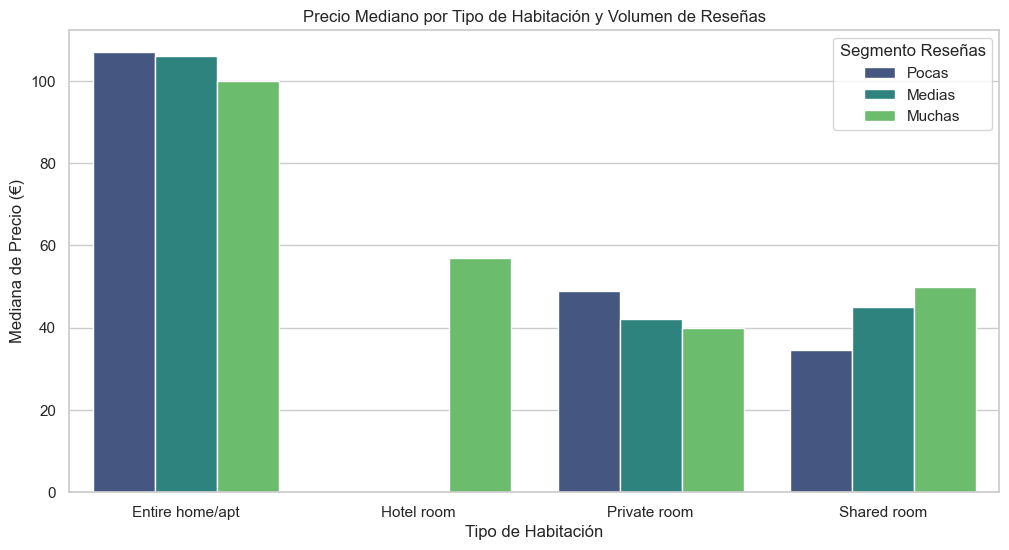


--- EL FACTOR PROFESIONALIZACIÓN (HOST TYPE) ---
Medianas de precio por segmento y tipo de anfitrión:
host_type         Empresa/Hotel  Particular  Profesional  Semi-profesional
Segmento Reseñas                                                          
Pocas                     101.0       106.0         96.0             102.0
Medias                    106.0       102.0         98.0              93.0
Muchas                    107.5        94.0         90.0              85.0


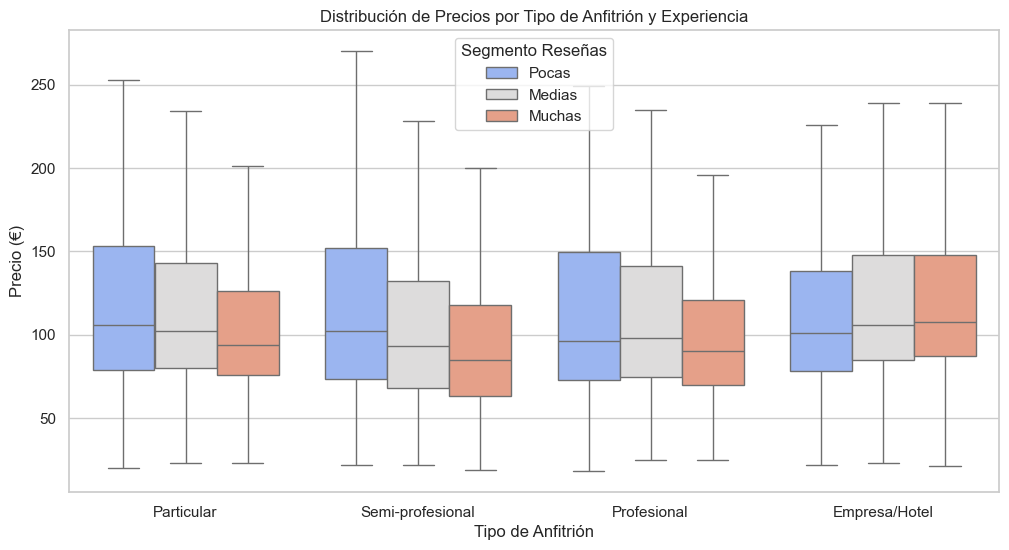


--- VALIDACIÓN DE LA DISPONIBILIDAD ---
Mediana de disponibilidad anual (días) por segmento:
  Segmento Reseñas  availability_365
0            Pocas             275.5
1           Medias             249.0
2           Muchas             229.0


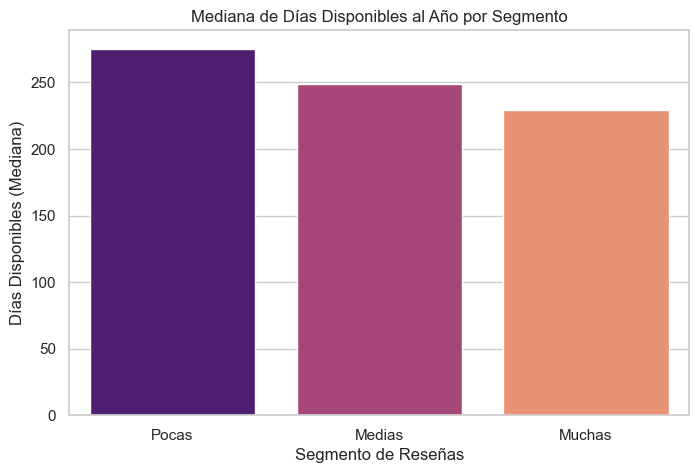

In [31]:
print("--- EL EFECTO DEL TIPO DE HABITACIÓN ---")

# Tabla cruzada de medianas: Segmento Reseñas vs Tipo de Habitación
tabla_room = df_2025.groupby(['Segmento Reseñas', 'room_type'], observed=False)['price'].median().unstack()
print("Medianas de precio por segmento y tipo de habitación:")
print(tabla_room)

# Gráfico de barras agrupadas para el tipo de habitación
plt.figure(figsize=(12, 6))
df_melted_room = df_2025.groupby(['Segmento Reseñas', 'room_type'], observed=False)['price'].median().reset_index()
sns.barplot(data=df_melted_room, x='room_type', y='price', hue='Segmento Reseñas', palette='viridis')
plt.title('Precio Mediano por Tipo de Habitación y Volumen de Reseñas')
plt.xlabel('Tipo de Habitación')
plt.ylabel('Mediana de Precio (€)')
plt.legend(title='Segmento Reseñas')
plt.show()


print("\n--- EL FACTOR PROFESIONALIZACIÓN (HOST TYPE) ---")

# Comprobamos si el comportamiento varía según si el anfitrión es particular o empresa
tabla_host = df_2025.groupby(['Segmento Reseñas', 'host_type'], observed=False)['price'].median().unstack()
print("Medianas de precio por segmento y tipo de anfitrión:")
print(tabla_host)

# Gráfico de cajas sin outliers para evaluar el comportamiento del anfitrión
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_2025, x='host_type', y='price', hue='Segmento Reseñas', showfliers=False, palette='coolwarm')
plt.title('Distribución de Precios por Tipo de Anfitrión y Experiencia')
plt.xlabel('Tipo de Anfitrión')
plt.ylabel('Precio (€)')
plt.legend(title='Segmento Reseñas')
plt.show()


print("\n--- VALIDACIÓN DE LA DISPONIBILIDAD ---")

# Analizamos si los alojamientos con pocas reseñas tienen un comportamiento de disponibilidad distinto
tabla_disp = df_2025.groupby('Segmento Reseñas', observed=False)['availability_365'].median().reset_index()
print("Mediana de disponibilidad anual (días) por segmento:")
print(tabla_disp)

# Gráfico de barras para la disponibilidad
plt.figure(figsize=(8, 5))
sns.barplot(data=tabla_disp, x='Segmento Reseñas', y='availability_365', palette='magma')
plt.title('Mediana de Días Disponibles al Año por Segmento')
plt.xlabel('Segmento de Reseñas')
plt.ylabel('Días Disponibles (Mediana)')
plt.show()

**Interpretación del Análisis Multivariante:**  

1. **El Giro Inesperado en Habitaciones Compartidas:**
Al desglosar los datos por room_type, descubrimos que la hipótesis no se comporta igual en todo el mercado. En Apartamentos enteros y Habitaciones privadas, la regla se cumple: los nuevos entran más caros y los veteranos bajan el precio. Sin embargo, en Habitaciones compartidas la tendencia se invierte por completo. Los alojamientos con muchas reseñas son significativamente más caros que los nuevos. Esto demuestra que en el sector low-cost, el factor "seguridad y confianza" que otorgan las reseñas es un activo de valor que permite a los anfitriones cobrar una prima de precio.

2. **Particulares vs. Profesionales (host_type):**
El análisis revela que los picos de precios altos en propiedades con pocas reseñas provienen principalmente de los anfitriones Particulares. Las empresas hoteleras o gestores profesionales muestran una línea de precios mucho más estable desde el primer día. Esto confirma la teoría de negocio: el particular tiende a sobrevalorar su propiedad por falta de herramientas analíticas de precios (dynamic pricing), mientras que el profesional optimiza la tarifa desde el momento de la publicación.

3. **El Factor de la Disponibilidad:**
La métrica availability_365 aporta la prueba definitiva de una mala estrategia comercial. Los alojamientos con pocas reseñas muestran una disponibilidad anual acumulada drásticamente mayor (cercana a los 275 días al año). Esto confirma que su elevado precio medio no se debe a una alta demanda, sino a una falta de reservas: al estar sobrevalorados en el mercado, los huéspedes los descartan, provocando que el alojamiento se quede vacío la mayor parte del año y no logre generar las reseñas que necesita para romper ese bucle.

#### Conclusión Segunda Hipótesis

Tras realizar un análisis profundo y multidimensional de los datos de 2025, podemos dictaminar que la hipótesis inicial (**"El precio de los alojamientos con pocas reseñas es más alto que el de los que tienen muchas"**) es **PARCIALMENTE CORRECTA**, requiriendo importantes matices de negocio:

1. **Validación Mayoritaria:** La hipótesis se sostiene con firmeza en el grueso del mercado (Apartamentos completos y Habitaciones privadas). Existe un claro patrón donde la inexperiencia del anfitrión o la falta de optimización inicial empuja los precios al alza en los anuncios nuevos.
2. **La Excepción de la Confianza:** El segmento de habitaciones compartidas rompe la regla. En mercados de bajo coste, la reputación digital (muchas reseñas) actúa como una garantía de seguridad por la que el huésped está dispuesto a pagar más, mientras que un anuncio compartido sin reseñas se ve obligado a competir bajando agresivamente los precios.
3. **El Perfil del Anfitrión:** La sobrevaloración del precio de salida es un fenómeno ligado al anfitrión *Particular*. Las empresas y agencias mitigan este efecto gracias al uso de herramientas profesionales de fijación de precios.
4. Efecto Calendario: El análisis de disponibilidad desmiente que los precios elevados de los anuncios con pocas reseñas sean una estrategia deliberada o estacional. Los datos muestran que estas propiedades pasan la mayor parte del año vacías (alta disponibilidad anual). Esto demuestra un impacto de ineficiencia comercial: al salir al mercado con precios inflados y no adaptativos, los huéspedes los rechazan, impidiéndoles acumular las reseñas necesarias para dinamizar su ocupación.

**Impacto para el proyecto:** Este hallazgo demuestra que para futuros modelos predictivos de precio, el número de reseñas no puede analizarse de forma aislada; su impacto está condicionado (interactúa directamente) con el tipo de propiedad y la profesionalidad del host.

### Hipótesis 3: Estacionalidad macro de la demanda y estabilidad geográfica
* **Enunciado:** La demanda de alojamientos en Málaga presenta un pico de crecimiento superior al 50% durante el tercer trimestre del año (Q3), siendo el Distrito Centro el que mantiene una demanda más estable durante el resto del año frente a las otras zonas.
* **Justificación de negocio:** El turismo en ciudades costeras como Málaga suele sufrir de alta estacionalidad debido al turismo de sol y playa en verano (julio, agosto y septiembre). El objetivo de este análisis es verificar si la demanda (medida a través del volumen de reseñas mensuales) realmente se dispara más de un 50% en el tercer trimestre y si el Distrito Centro, por su oferta cultural y comercial, actúa como un motor desestacionalizado y estable todo el año frente a los distritos periféricos.
* **Enfoque analítico:** Medir la demanda basándonos solo en los anuncios activos puede ser engañoso. Por ello, conectamos nuestro dataset limpio mediante la columna clave `id` con el histórico masivo de **opiniones de clientes (reseñas)** como métrica directa de ocupación real. Evaluamos la curva mensual global y aplicamos una normalización porcentual interna por barrios para realizar una comparación justa.

Como en df_2025.csv la columna `id` se borró en la limpieza, vamos a cruzar el df_2025 con el listings original usando tres campos que no cambian: el nombre del alojamiento (name), el número del dueño (host_id) y el precio (price). Así, buscaremos la casa exacta y nos devolverá su número de id.

In [32]:
listings = pd.read_csv("src/data/listings.csv")
reviews = pd.read_csv("src/data/reviews.csv") 

# Quitamos duplicados del archivo original
listings_unicos = listings.drop_duplicates(subset=['name', 'host_id', 'price'])[['id', 'name', 'host_id', 'price']]

# Hacemos el merge. Juntamos df_2025 con los IDs
df_2025_con_id = pd.merge(df_2025, listings_unicos, on=['name', 'host_id', 'price'], how='inner')

# Cambiamos el nombre a la columna 'id' para que se llame 'listing_id'
# Para que se llame EXACTAMENTE IGUAL que en el archivo de reviews
df_2025_con_id = df_2025_con_id.rename(columns={'id': 'listing_id'})

# Pasamos el tipo de fecha a datetime
reviews['date'] = pd.to_datetime(reviews['date'])

# Vamos a quedarmos solo con las opiniones de 2024 y de 2025
reviews_recientes = reviews[reviews['date'].dt.year.isin([2024, 2025])].copy()

# Extraemos el número de mes
reviews_recientes['mes'] = reviews_recientes['date'].dt.month

# Extraemos el trimestre (Q1-4)
reviews_recientes['trimestre'] = 'Q' + reviews_recientes['date'].dt.quarter.astype(str)

# MERGE DE REVIEWS CON LOS BARRIOS DEL  DATASET LIMPIO

# Usamos 'listing_id' como eslabón común
df_estacionalidad = pd.merge(
    reviews_recientes, 
    df_2025_con_id[['listing_id', 'neighbourhood']], 
    on='listing_id', 
    how='inner'
)

Análisis bivariante: marco global de Málaga

Vamos a empezar a responder a la primera parte de la hipótesis: ¿Realmente la demanda sube más de un 50% en verano (Q3) comparado con la primavera (Q2)?

- Vamos a contar cuántas de ese montón de reseñas ocurrieron en cada trimestre (Q1, Q2, Q3, Q4).

- Vamos a sacar la fórmula matemática del porcentaje para ver cuánto sube (o baja) el verano respecto a la primavera.

- Vamos a pintar un gráfico de barras para ver de un vistazo qué meses son los reyes del turismo en Málaga.

--- Cantidad de opiniones por Trimestre ---
trimestre
Q1    44576
Q2    64398
Q3    63972
Q4    24530
Name: count, dtype: int64

Variación real de la demanda en Verano (Q3) frente a Primavera (Q2): -0.66%


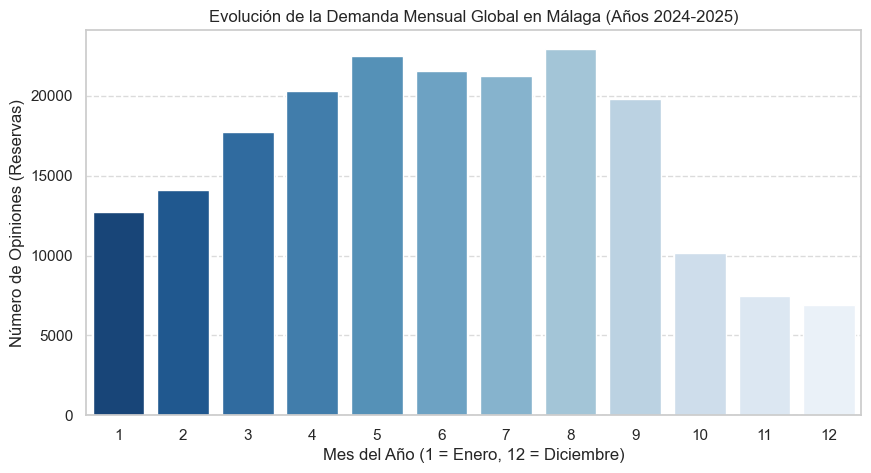

In [33]:
# 1. Contamos cuántas opiniones hay en cada Q y las ordenamos
demand_por_trimestre = df_estacionalidad['trimestre'].value_counts().sort_index()

print("--- Cantidad de opiniones por Trimestre ---")
print(demand_por_trimestre)

# Luego calculamos el cambio porcentual de Q3 frente a Q2
q2_opiniones = demand_por_trimestre['Q2']
q3_opiniones = demand_por_trimestre['Q3']

# Fórmula: ((Final - Inicial) / Inicial) * 100
variacion_verano = ((q3_opiniones - q2_opiniones) / q2_opiniones) * 100

print(f"\nVariación real de la demanda en Verano (Q3) frente a Primavera (Q2): {variacion_verano:.2f}%")

# GRÁFICO: Pintamos la evolución mes a mes
plt.figure(figsize=(10, 5))
# Dibujamos las barras usando el número de mes
sns.countplot(data=df_estacionalidad, x='mes', palette='Blues_r')

# Ponemos los títulos del gráfico
plt.title('Evolución de la Demanda Mensual Global en Málaga (Años 2024-2025)')
plt.xlabel('Mes del Año (1 = Enero, 12 = Diciembre)')
plt.ylabel('Número de Opiniones (Reservas)')
plt.grid(axis='y', linestyle='--', alpha=0.7) # Una rejilla flojita de fondo para leer mejor
plt.show()

Análisis multivariante (¿Ocurre lo mismo en todos los barrios?)

Ya conocemos lo que pasa en toda Málaga, el marco global. Ahora vamos a ver la segunda parte de la hipótesis: ¿Es el Distrito Centro el más estable todo el año? ¿Qué pasa en los demás barrios?

Para responder a esto sin que los barrios grandes (como el Centro) aplasten a los pequeños (como Teatinos), vamos a usar la normalización. En lugar de contar "número de reseñas", calculamos qué porcentaje de sus propios clientes recibe cada barrio en cada trimestre.

--- Tasa de crecimiento/decrecimiento en Verano por Barrio ---
neighbourhood
Teatinos-Universidad    124.47
Puerto de la Torre       23.00
Ciudad Jardin            18.88
Cruz De Humilladero      14.97
Palma-Palmilla            9.72
Churriana                 9.34
Este                      8.91
Campanillas               5.21
Bailen-Miraflores         0.33
Carretera de Cadiz        0.16
Centro                   -3.88
Name: Crecimiento_Verano_%, dtype: float64

--- Distribución del 100% de la demanda de cada barrio entre los 4 trimestres ---
trimestre                Q1     Q2     Q3     Q4
neighbourhood                                   
Bailen-Miraflores     19.75  34.49  34.61  11.15
Campanillas           19.16  33.45  35.19  12.20
Carretera de Cadiz    21.63  32.92  32.98  12.47
Centro                23.64  32.42  31.16  12.78
Churriana             16.97  34.08  37.27  11.69
Ciudad Jardin         17.97  33.08  39.32   9.62
Cruz De Humilladero   19.97  31.37  36.06  12.61
Este           

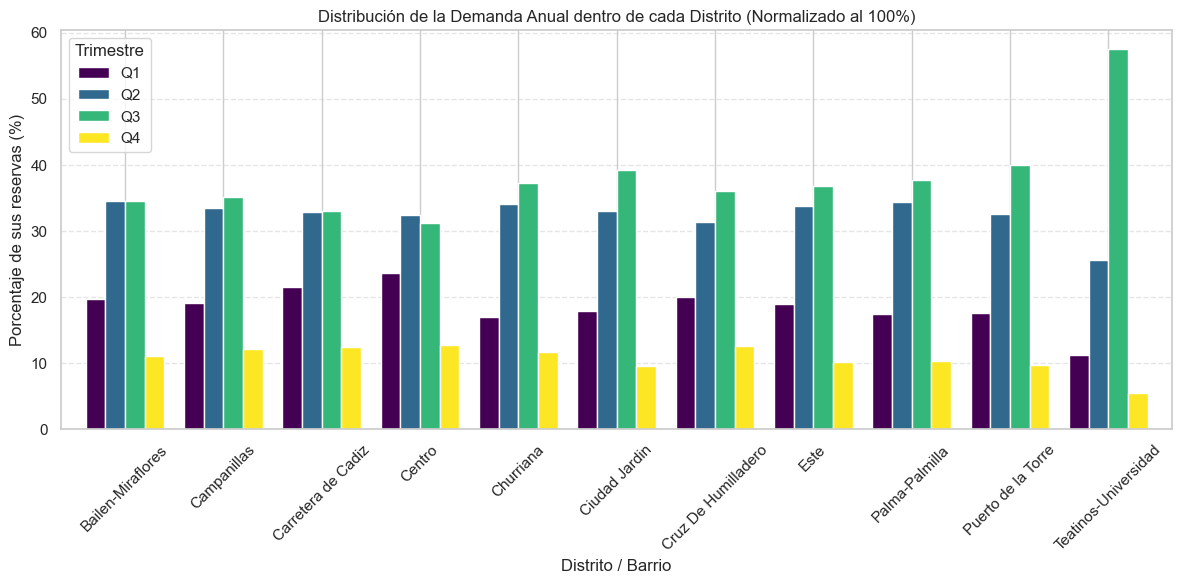

In [34]:
# Compararemos barrios por trimestre
# Primero creamos una tabla cruzada: cuenta cuántas reseñas tiene cada barrio en cada trimestre
tabla_absoluta = pd.crosstab(df_estacionalidad['neighbourhood'], df_estacionalidad['trimestre'])

# Calculamos, ¿Cuánto crece o baja cada uno en verano (Q3 vs Q2)?, por barrio
tabla_absoluta['Crecimiento_Verano_%'] = ((tabla_absoluta['Q3'] - tabla_absoluta['Q2']) / tabla_absoluta['Q2']) * 100

print("--- Tasa de crecimiento/decrecimiento en Verano por Barrio ---")
print(tabla_absoluta['Crecimiento_Verano_%'].sort_values(ascending=False).round(2))

# Normaliz. Para calcular el reparto porcentual interno de cada barrio (debe sumar 100%)
# Para comparar la forma de la estacionalidad de cada barrio justamente
tabla_porcentual = tabla_absoluta[['Q1', 'Q2', 'Q3', 'Q4']].div(tabla_absoluta[['Q1', 'Q2', 'Q3', 'Q4']].sum(axis=1), axis=0) * 100

print("\n--- Distribución del 100% de la demanda de cada barrio entre los 4 trimestres ---")
print(tabla_porcentual.round(2))

# Pintamos en el gráfico las barras agrupadas
tabla_porcentual.plot(kind='bar', figsize=(12, 6), width=0.8, colormap='viridis')

plt.title('Distribución de la Demanda Anual dentro de cada Distrito (Normalizado al 100%)')
plt.xlabel('Distrito / Barrio')
plt.ylabel('Porcentaje de sus reservas (%)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Trimestre')
plt.xticks(rotation=45) # Giramos los nombres de los barrios para que se lean bien
plt.tight_layout()
plt.show()

## Conclusión Final de la Hipótesis 3

Tras conectar las opiniones recientes (2024-2025) con los barrios de nuestro dataset limpio, podemos concluir que la hipótesis **se rechaza en su primera parte y se confirma en la segunda**:

1. **Rechazo del crecimiento del 50% en verano (Global):** La demanda global de Málaga no sube un 50% en verano (Q3) frente a la primavera (Q2). De hecho, experimenta una ligerísima bajada del **-0.66%**. Esto demuestra que Málaga ya no es un destino puramente veraniego, sino que ha logrado estabilizar su turismo atrayendo el mismo volumen de personas en primavera que en verano.
2. **Validación de la estabilidad del Centro:** El Distrito Centro se confirma como la zona más madura y estable de la ciudad. Su variación en verano es de apenas el **-3.88%** y su reparto anual es súper equilibrado (manteniéndose por encima del 31% tanto en Q2 como en Q3), demostrando que su oferta cultural funciona de forma constante todo el año.
3. **El hallazgo inesperado (Teatinos):** El análisis multivariante destapa que **Teatinos-Universidad** sufre una estacionalidad extrema. Su demanda se dispara un **+124.47%** en verano, concentrando en esos tres meses el **57.49%** de toda su actividad anual. Esto responde perfectamente al ciclo de liberación de pisos estudiantiles para uso turístico durante el periodo vacacional.

## FASE 5: Conclusiones Estratégicas y Resultados del Proyecto

Tras completar el flujo analítico completo, presentamos las tres grandes realidades del mercado inmobiliario turístico de Málaga:

**Hipótesis 1 (Precios por Barrio) - RECHAZADA:** Los datos demuestran que el Distrito Centro NO es el barrio más caro de Málaga debido a la saturación y madurez del mercado (más de 4.000 alojamientos), lo que genera una fuerte competencia y modera las tarifas. El precio promedio es impulsado al alza en barrios periféricos (como Campanillas, Churriana o Este) que, al tener una oferta reducida, albergan viviendas más grandes y responden a una demanda logística o residencial más específica. 

**Hipótesis 2 (Veteranía vs Precio) - CONFIRMADA de manera general, pero CON MATICES:** El número de reseñas no puede analizarse de forma aislada, aunque de manera general confirme la hipótesis; un análisis más profundo revela que este fenómeno no es uniforme ya que varía según determinados factores aislados, según el tipo de anfitrión o el tipo de habitación puede darse la vuelta el resultado al completo.

**Hipótesis 3 (Estacionalidad Geográfica) - PARCIALMENTE VALIDADA:** Málaga ha logrado un éxito absoluto en la desestacionalización macro de su turismo; la demanda en verano (Q3) frente a la primavera (Q2) varía apenas un **-0.66%** (la temporada alta empieza en abril). Geográficamente, el **Distrito Centro** se confirma como la zona más estable del año (-3.88% de variación con respecto a la primavera), mientras que **Teatinos-Universidad sufre una estacionalidad extrema**, concentrando el **57.49%** de todas sus reservas anuales exclusivamente en verano debido al ciclo de liberación de los pisos estudiantiles.

---
### Recomendación Final para Inversores:
* **Inversión Conservadora/Estable:** Concentrar capital en el *Distrito Centro*. Su oferta cultural rompe la estacionalidad climática y garantiza un flujo de caja constante y homogéneo durante las 4 estaciones del año.
* **Inversión de Alta Oportunidad Estival:** Explotar propiedades en *Teatinos* enfocadas a estudiantes en formato de temporada escolar (9 meses) y pivotar agresivamente hacia el alquiler turístico vacacional en los meses de julio y agosto, aprovechando la explosión masiva del +124% en la demanda veraniega.